# Session 11 - Live Demo: Auditing COMPAS with AI Fairness 360

**Research Methods & Scientific Integrity in AI** - Doctoral Program in Deep Technologies, UNMSM
**Instructor:** Dr. Loveleen Gaur

This is the instructor screen-share notebook for Block 4. It runs the five-move audit shown on the slides:

1. **Load** COMPAS with `race` as the protected attribute
2. **Measure** disparate impact and statistical parity on the raw data
3. **Diagnose** against the four-fifths (0.8) rule
4. **Mitigate** with Reweighing, then retrain a classifier
5. **Re-measure** and name the accuracy / fairness trade-off out loud

> **A note on the data.** COMPAS is a real dataset about real people who were assigned risk scores. In AIF360 the *favorable* outcome is "did not re-offend within two years." We are auditing a model that predicts recidivism; the point is to see how its errors fall unequally across racial groups, exactly as ProPublica documented in 2016.

## Move 0 - Setup

In [1]:
# --- One-time setup (Colab): install the fairness toolkits ---
# AIF360 = IBM AI Fairness 360.  Fairlearn = Microsoft's fairness library.
!pip -q install aif360 fairlearn

import warnings, os, urllib.request
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from aif360.datasets import CompasDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing

print("Toolkits ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.3 MB/s eta 0:00:00


pip install 'aif360[inFairness]'


Toolkits ready.


In [2]:
# --- Fetch the COMPAS data that AIF360 expects (not bundled, for licensing reasons) ---
# This copies ProPublica's public two-year recidivism CSV into AIF360's data folder.
import aif360
compas_dir = os.path.join(os.path.dirname(aif360.__file__), "data", "raw", "compas")
os.makedirs(compas_dir, exist_ok=True)
csv_path = os.path.join(compas_dir, "compas-scores-two-years.csv")
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
if not os.path.exists(csv_path):
    urllib.request.urlretrieve(url, csv_path)
    print("Downloaded COMPAS data.")
else:
    print("COMPAS data already present.")

Downloaded COMPAS data.


In [3]:
# --- A tiny helper so BEFORE and AFTER are measured the exact same way ---
def audit(clf_dataset_true, clf_dataset_pred, unpriv, priv):
    # Return the fairness + accuracy numbers we care about for this session.
    cm = ClassificationMetric(clf_dataset_true, clf_dataset_pred,
                              unprivileged_groups=unpriv, privileged_groups=priv)
    return {
        "Accuracy":                    cm.accuracy(),
        "Disparate impact":            cm.disparate_impact(),               # want close to 1.0 (>= 0.8)
        "Statistical parity diff":     cm.statistical_parity_difference(),  # want close to 0
        "Equal opportunity diff":      cm.equal_opportunity_difference(),   # want close to 0
        "Average odds diff":           cm.average_odds_difference(),        # want close to 0
    }

def fourfifths_flag(di):
    # The 80% rule of thumb used by regulators (e.g. NYC Local Law 144).
    return "PASS (>= 0.8)" if di >= 0.8 else "FAIL (< 0.8): potential disparate impact"


## Move 1 - Load COMPAS and define the groups

In [4]:
dataset = CompasDataset()

# race is coded 1 = Caucasian (privileged here), 0 = African-American (unprivileged)
privileged_groups   = [{"race": 1}]
unprivileged_groups = [{"race": 0}]

train, test = dataset.split([0.7], shuffle=True, seed=42)
print("Train rows:", train.features.shape[0], " Test rows:", test.features.shape[0])
print("Protected attributes:", dataset.protected_attribute_names)
print("Favorable label (1 = did NOT re-offend):", dataset.favorable_label)

Train rows: 4316  Test rows: 1851
Protected attributes: ['sex', 'race']
Favorable label (1 = did NOT re-offend): 0.0


## Move 2 - Measure bias in the raw data (before any model)

In [5]:
raw = BinaryLabelDatasetMetric(train,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)

print(f"Disparate impact (data):        {raw.disparate_impact():.3f}")
print(f"Statistical parity diff (data): {raw.mean_difference():.3f}")
# A value of 1.0 / 0.0 would mean the favorable label is distributed equally across groups.

Disparate impact (data):        0.850
Statistical parity diff (data): -0.090


## Move 3 - Train a baseline classifier, then diagnose it

In [6]:
scaler  = StandardScaler().fit(train.features)
X_train = scaler.transform(train.features)
X_test  = scaler.transform(test.features)
y_train = train.labels.ravel()

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

# wrap predictions back into an AIF360 dataset so we can score fairness on them
test_pred = test.copy()
test_pred.labels = baseline.predict(X_test).reshape(-1, 1)

before = audit(test, test_pred, unprivileged_groups, privileged_groups)
print("BEFORE mitigation")
for k, v in before.items():
    print(f"  {k:28s}: {v: .3f}")
print("  Four-fifths rule           :", fourfifths_flag(before["Disparate impact"]))

BEFORE mitigation
  Accuracy                    :  0.664
  Disparate impact            :  0.773
  Statistical parity diff     : -0.165
  Equal opportunity diff      : -0.095
  Average odds diff           : -0.139
  Four-fifths rule           : FAIL (< 0.8): potential disparate impact


## Move 4 - Mitigate with Reweighing (pre-processing), then retrain

In [7]:
RW = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
train_rw = RW.fit_transform(train)

# Reweighing changes only the per-row training weights, not the features or labels.
mitigated = LogisticRegression(max_iter=1000)
mitigated.fit(X_train, y_train, sample_weight=train_rw.instance_weights)

test_pred_rw = test.copy()
test_pred_rw.labels = mitigated.predict(X_test).reshape(-1, 1)

after = audit(test, test_pred_rw, unprivileged_groups, privileged_groups)
print("AFTER mitigation (Reweighing)")
for k, v in after.items():
    print(f"  {k:28s}: {v: .3f}")
print("  Four-fifths rule           :", fourfifths_flag(after["Disparate impact"]))

AFTER mitigation (Reweighing)
  Accuracy                    :  0.653
  Disparate impact            :  0.975
  Statistical parity diff     : -0.016
  Equal opportunity diff      :  0.031
  Average odds diff           :  0.015
  Four-fifths rule           : PASS (>= 0.8)


## Move 5 - Compare, and name the trade-off

In [8]:
compare = pd.DataFrame({"Before": before, "After (Reweighing)": after})
compare["Change"] = compare["After (Reweighing)"] - compare["Before"]
display(compare.round(3))

acc_cost = before["Accuracy"] - after["Accuracy"]
di_gain  = after["Disparate impact"] - before["Disparate impact"]
print(f"\nDisparate impact moved by {di_gain:+.3f} toward parity.")
print(f"Accuracy changed by {(-acc_cost):+.3f}.  There is no free lunch: state the cost.")

,Before,After (Reweighing),Change
Accuracy,0.664,0.653,-0.011
Disparate impact,0.773,0.975,0.202
Statistical parity diff,-0.165,-0.016,0.149
Equal opportunity diff,-0.095,0.031,0.125
Average odds diff,-0.139,0.015,0.154



Disparate impact moved by +0.202 toward parity.
Accuracy changed by -0.011.  There is no free lunch: state the cost.


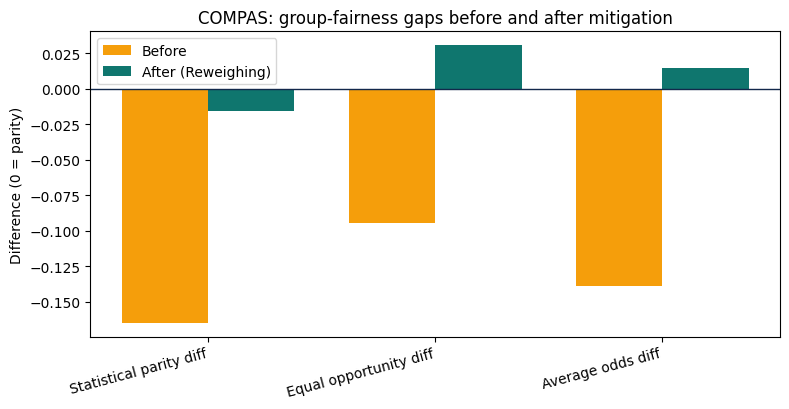

In [9]:
# Visual: fairness metrics before vs after (0 = perfectly fair for the difference metrics)
labels = ["Statistical parity diff", "Equal opportunity diff", "Average odds diff"]
b = [before[k] for k in labels]
a = [after[k]  for k in labels]
x = np.arange(len(labels)); w = 0.38

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(x - w/2, b, w, label="Before",           color="#F59E0B")
ax.bar(x + w/2, a, w, label="After (Reweighing)", color="#0F766E")
ax.axhline(0, color="#12284B", lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Difference (0 = parity)")
ax.set_title("COMPAS: group-fairness gaps before and after mitigation")
ax.legend(); plt.tight_layout(); plt.show()

## Bonus - the impossibility theorem, in three lines

Chouldechova (2017) and Kleinberg et al. (2016) proved that when base rates differ across groups, you cannot have equal predictive value (calibration) **and** equal false-positive **and** equal false-negative rates at once. The cell below shows COMPAS satisfying one notion while failing another, which is exactly the ProPublica vs Northpointe dispute.

In [ ]:
cm = ClassificationMetric(test, test_pred,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)

# Predictive parity view (Northpointe's claim): precision by group
ppv_unpriv = cm.positive_predictive_value(privileged=False)
ppv_priv   = cm.positive_predictive_value(privileged=True)

# Equalized-odds view (ProPublica's claim): false-positive rate by group
fpr_unpriv = cm.false_positive_rate(privileged=False)
fpr_priv   = cm.false_positive_rate(privileged=True)

print("Predictive value (precision) - roughly EQUAL is Northpointe's 'it's fair':")
print(f"   unprivileged: {ppv_unpriv:.3f}   privileged: {ppv_priv:.3f}")
print("\nFalse-positive rate - UNEQUAL is ProPublica's 'it's biased':")
print(f"   unprivileged: {fpr_unpriv:.3f}   privileged: {fpr_priv:.3f}")
print("\nBoth readings are mathematically correct. Choosing which one matters is an ethical decision.")